In [2]:
import pandas as pd
from src.calculators import IRDCalculator

In [3]:
df_ipp = pd.read_excel('./outputs/df_ipp_v2f.xlsx')
df_eindex = pd.read_csv('./outputs/df_for_ird.csv')
df_parls = pd.read_csv('./data/df_parl_detalhes.csv')

In [4]:
df_for_equality = pd.read_csv("./outputs/df_for_ird.csv")
df_for_equality.set_index(["id", "idLegislatura"], inplace=True)

df_legislatura = df_for_equality.loc[pd.IndexSlice[:, 56], :]

population_proportions = {
    "F": 0.52,
    "M": 0.48,
    "branca": 0.2,
    "n_branca": 0.8,
}

calculator = IRDCalculator()
df_calc = calculator.calculate(
    df_legislatura,
    population_proportions,
)

print(df_calc)

                      F  M  branca  n_branca  equality_weight  \
id     idLegislatura                                            
204554 56             0  1       0         1         0.952840   
204521 56             0  1       1         0         0.207262   
204379 56             0  1       1         0         0.207262   
204560 56             0  1       1         0         0.207262   
204528 56             1  0       1         0         0.942056   
...                  .. ..     ...       ...              ...   
204559 56             0  1       0         1         0.952840   
160632 56             0  1       1         0         0.207262   
204517 56             0  1       1         0         0.207262   
178923 56             0  1       1         0         0.207262   
160592 56             0  1       1         0         0.207262   

                      equality_weight_normalized  equality_index_normalized  
id     idLegislatura                                                        

In [10]:
df_merge = df_ipp.merge(df_calc.reset_index(), on=['id', 'idLegislatura'])

In [11]:
df_merge

,Unnamed: 0,id,idLegislatura,ultimoStatus.nome,ultimoStatus.siglaPartido,sexo,dataNascimento,escolaridade,idade_posse,tempo_atuacao_dias_cum_ln,...,dim_comprometimento_norm,dim_carreira_norm,ipp,F,M,branca,n_branca,equality_weight,equality_weight_normalized,equality_index_normalized
0,58,62881,56,Danilo Forte,UNIÃO,M,1958-09-01,Superior,52,8.248791,...,0.292315,0.495494,0.393904,0,1,1,0,0.207262,0.001107,0.72712
1,95,66179,56,Norma Ayub,PP,F,1959-09-07,Superior,55,7.705262,...,0.034278,0.414757,0.224517,1,0,1,0,0.942056,0.002309,0.72712
2,102,66828,56,Fausto Pinato,PP,M,1977-06-01,Superior,37,7.979681,...,0.138321,0.426488,0.282404,0,1,1,0,0.207262,0.001107,0.72712
3,107,67138,56,Iracema Portella,PP,F,1966-04-23,Superior,44,8.357024,...,0.044186,0.442618,0.243402,1,0,1,0,0.942056,0.002309,0.72712
4,117,68720,56,Fábio Henrique,UNIÃO,M,1972-06-19,Superior,46,7.286876,...,0.042090,0.339369,0.190730,0,1,1,0,0.207262,0.001107,0.72712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,6199,221147,56,Marcia Scherer,MDB,F,1969-11-05,Superior,49,3.433987,...,0.000000,0.117165,0.058582,1,0,1,0,0.942056,0.002309,0.72712
609,6200,221148,56,Alfredinho,PT,M,1959-06-24,Ensino Médio,59,3.433987,...,0.000000,0.174667,0.087334,0,1,0,1,0.952840,0.002334,0.72712
610,6202,221149,56,Elói Pietá,PT,M,1944-08-10,Superior,74,3.433987,...,0.000000,0.174667,0.087334,0,1,1,0,0.207262,0.001107,0.72712
611,6203,221157,56,Rui Godinho,UNIÃO,M,1979-03-22,Superior,39,3.401197,...,0.000000,0.173265,0.086633,0,1,0,1,0.952840,0.002334,0.72712


<Axes: xlabel='equality_weight', ylabel='ipp'>

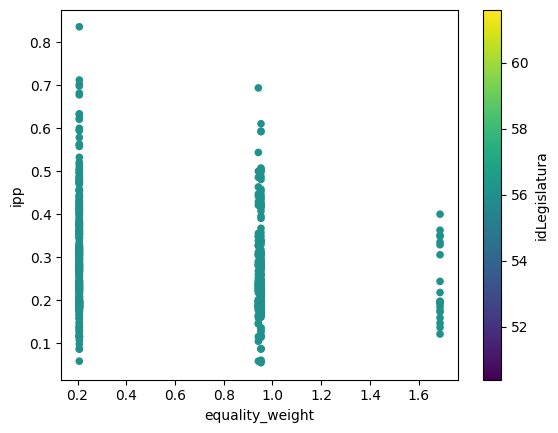

In [7]:
df_merge.plot(x='equality_weight', y='ipp', kind='scatter', c='idLegislatura', cmap='viridis')

In [16]:
df_merge.to_excel("df_dash.xlsx")